In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data\online_retail_II_full.csv')

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\hj161\AppData\Local\Temp\ipykernel_18904\422502667.py:1: SyntaxWarning: invalid escape sequence '\o'
  df = pd.read_csv('data\online_retail_II_full.csv')


In [3]:
df.head()

,invoice,stockcode,quantity,invoice_date,price,customer_id,country,total_price
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [4]:
df.drop(columns=['stockcode','quantity','price','country'],inplace=True)

In [5]:
df

,invoice,invoice_date,customer_id,total_price
0,489434,2009-12-01 07:45:00,13085,83.40
1,489434,2009-12-01 07:45:00,13085,81.00
2,489434,2009-12-01 07:45:00,13085,81.00
3,489434,2009-12-01 07:45:00,13085,100.80
4,489434,2009-12-01 07:45:00,13085,30.00
...,...,...,...,...
805544,581587,2011-12-09 12:50:00,12680,12.60
805545,581587,2011-12-09 12:50:00,12680,16.60
805546,581587,2011-12-09 12:50:00,12680,16.60
805547,581587,2011-12-09 12:50:00,12680,14.85


In [5]:
df['invoice_date']=pd.to_datetime(df['invoice_date'])

In [6]:
reference_date = df['invoice_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('invoice_date', lambda x: (reference_date - x.max()).days),
    frequency = ('invoice', 'nunique'),
    monetary  = ('total_price', 'sum')
).reset_index()

In [7]:
print(rfm.head())

   customer_id  recency  frequency  monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40


In [8]:
# --- Scoring ---
rfm['r_score'] = pd.qcut(rfm['recency'],  q=5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5])

In [9]:
print(rfm[['r_score', 'f_score', 'm_score']].head(10))

  r_score f_score m_score
0       2       5       5
1       5       4       5
2       3       4       4
3       5       3       5
4       2       1       2
5       2       1       2
6       4       5       4
7       2       2       2
8       2       1       3
9       2       2       3


In [10]:
# --- Combine scores ---
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# --- Segment mapping function ---
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['segment'].value_counts())

segment
Champions          1300
Lost               1275
Loyal Customers    1134
Need Attention     1111
At Risk             615
Promising           443
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\hj161\AppData\Local\Temp\ipykernel_18904\2953067116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm, x='segment', palette='viridis',


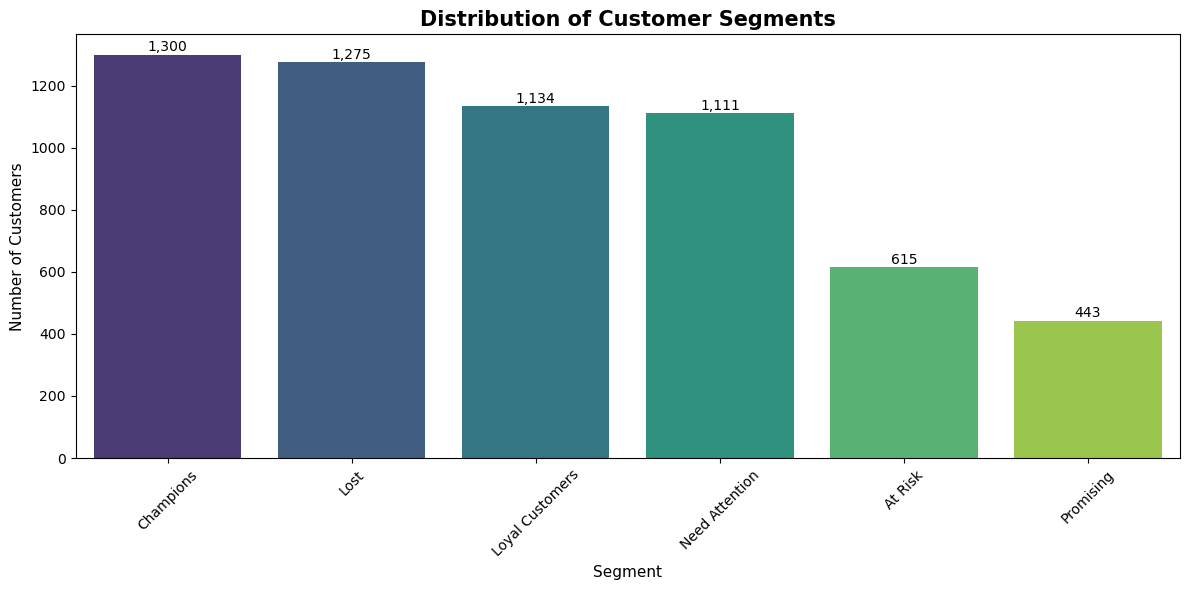

In [14]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=rfm, x='segment', palette='viridis', 
                   order=rfm['segment'].value_counts().index)

# Add count labels on top of bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.title('Distribution of Customer Segments', fontsize=15, fontweight='bold')
plt.xlabel('Segment', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/chart7_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
segment_summary = rfm.groupby('segment').agg(
    avg_recency   = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary', 'mean'),
    customer_count= ('customer_id', 'count')
).round(1).sort_values('avg_monetary', ascending=False)

print(segment_summary)

                 avg_recency  avg_frequency  avg_monetary  customer_count
segment                                                                  
Champions               20.0           17.1        9329.3            1300
At Risk                359.5            5.6        2517.2             615
Loyal Customers         73.4            5.9        2295.6            1134
Promising               28.1            1.5         890.8             443
Need Attention         219.8            2.2         667.6            1111
Lost                   467.8            1.2         257.0            1275


In [20]:
rfm_segments=segment_summary
rfm_segments

,avg_recency,avg_frequency,avg_monetary,customer_count
segment,,,,
Champions,20.0,17.1,9329.3,1300
At Risk,359.5,5.6,2517.2,615
Loyal Customers,73.4,5.9,2295.6,1134
Promising,28.1,1.5,890.8,443
Need Attention,219.8,2.2,667.6,1111
Lost,467.8,1.2,257.0,1275


In [ ]:
rfm_segments.to_csv('data/rfm_segments.csv', index=True)